# Phase-changing flash as a complementarity problem

A single vapour--liquid equilibrium stage, solved across a temperature path that
crosses **single-liquid, two-phase and single-vapour**, written so that the number
of variables and equations never changes at a phase boundary. The phase logic is
carried by two complementarity conditions, and the whole thing is handed to POUNCE
as one nonlinear program with exact derivatives.

This is the Gate 1 fixture of
[gh#776](https://github.com/jkitchin/pounce/issues/776). Gate 0
([gh#794](https://github.com/jkitchin/pounce/issues/794),
[`benchmarks/mpcc/`](https://github.com/jkitchin/pounce/tree/main/benchmarks/mpcc))
established which POUNCE route is supported for small MPCCs on a corpus that was
deliberately *not* a process model. This notebook is the first model with physics in
it, and it deliberately stops at one flash: no tray, no column, no dynamics.

**What this notebook is, and is not.**

* It **is** a correctness demonstration: every answer is checked against an
  independent flash and stability calculation, on a problem whose answer is known
  by other means. That is the point of doing it before anything larger.
* It is **not** a claim that complementarity is a better way to solve one flash.
  Measured below, ordinary successive substitution wins on this problem by an order
  of magnitude, and the notebook says so with numbers.
* It is **not** a property package, a tray model, or evidence about anything with
  more than one equilibrium stage.

The model and its oracle are `pounce.examples.flash_mpcc`; the evidence harness
that runs the full route matrix is `benchmarks/flash/`.

In [1]:
%matplotlib inline
from pathlib import Path
import platform, subprocess, sys, time

repo_root = Path.cwd()
if not (repo_root / "python" / "pounce").is_dir():
    repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "python"))

import jax
import matplotlib.pyplot as plt
import numpy as np
import scipy
import pounce
from pounce.examples.flash_mpcc import (
    GATE1_FLASH, PAIRS, CORNER_TOL, SOLVE_TOL,
    bubble_and_dew, flash, is_trivial, lower, ln_phi,
    rachford_rice, root_diagnostics, tangent_plane, wilson_k,
)

def _git(*a):
    try:
        return subprocess.check_output(["git", *a], cwd=repo_root, text=True).strip()
    except Exception:
        return "unknown"

case = GATE1_FLASH
print("commit           ", _git("describe", "--always", "--dirty"))
print("python / platform", platform.python_version(), "/", platform.platform())
print("pounce / jax     ", pounce.__version__, "/", jax.__version__)
print("numpy / scipy    ", np.__version__, "/", scipy.__version__)
print()
print("case             ", case.name)
print("components       ", case.mixture.names, " feed", case.z)
print("pressure [bar]   ", case.pressure_pa / 1e5)
print("equation of state Peng-Robinson, classical one-fluid mixing, k_ij = 0")
print("constants        ", case.mixture.source)
print("path             ", f"{len(case.temperatures_k)} temperatures, "
                           f"{case.temperatures_k.min()}-{case.temperatures_k.max()} K")
print("solver tolerance ", SOLVE_TOL, " complementarity floor sqrt(tol) =", f"{CORNER_TOL:.0e}")

commit            f49eaaf
python / platform 3.11.15 / Linux-6.18.44-fc-v24-x86_64-with-glibc2.39
pounce / jax      0.11.0 / 0.10.2
numpy / scipy     2.4.6 / 1.17.1

case              ethane_n_butane_10bar
components        ('ethane', 'n-butane')  feed [0.5 0.5]
pressure [bar]    10.0
equation of state Peng-Robinson, classical one-fluid mixing, k_ij = 0
constants         Ethane and n-butane rows of phase_envelope.NATURAL_GAS (notebook 34 natural-gas demonstration); k_ij = 0.
path              34 temperatures, 230.0-360.0 K
solver tolerance  1e-08  complementarity floor sqrt(tol) = 1e-04


## 1. Why phase appearance is awkward

Write a flash the obvious way and the model has a different *shape* in each regime.
Below the bubble point there is no vapour, so there are no vapour equations to write;
inside the two-phase region there are. A simulator handles this by branching: run a
stability test, decide the regime, then instantiate the equations that regime needs.

That branch is invisible and harmless as long as the flash is the whole problem. It
stops being harmless the moment the flash is *one block inside something larger* --
a tray in a column, a stage in a dynamic startup transcription with a control
objective. A simultaneous transcription cannot change dimension halfway through a
time horizon, and an outer optimiser cannot differentiate through a branch that
re-decides which equations exist.

Complementarity is the standard way out. Instead of "if the vapour is present, write
the equilibrium equations", write

$$0 \le (\text{amount of vapour}) \perp (\text{vapour stability slack}) \ge 0$$

which says *the vapour amount is zero **or** its stability condition is active* -- and
says it with a fixed number of variables in every regime. Raghunathan, Díaz and Biegler
did exactly this for distillation in 2004; this notebook is one stage of it.

The price is stated up front: an MPCC violates the standard constraint qualifications
at every feasible point. That is a theorem about the reformulation, not a defect of any
particular one, and it is why the answers below are checked against something else
rather than trusted because the solver said `Solve_Succeeded`.

## 2. The honest baseline: successive substitution wins on one flash

Before claiming anything for the complementarity form, here is the conventional
method it would replace. Successive substitution updates $K_i$ from the fugacity
coefficients and re-solves Rachford--Rice each sweep:

In [2]:
def naive_flash(T, iters=500, tol=1e-12):
    """Textbook successive substitution from a Wilson start.

    No stability test, no complementarity: update K from the fugacity
    coefficients, re-solve Rachford-Rice, repeat. Rachford-Rice clips
    beta into [0, 1], which is what makes the single-phase regimes
    'work' -- and what we come back to below.
    """
    K = wilson_k(T, case.pressure_pa, case.mixture)
    for i in range(iters):
        beta = rachford_rice(case.z, K)
        x = case.z / (1.0 + beta * (K - 1.0))
        y = K * x
        lx = np.asarray(ln_phi(x / x.sum(), T, case.pressure_pa, case.mixture, largest=False))
        ly = np.asarray(ln_phi(y / y.sum(), T, case.pressure_pa, case.mixture, largest=True))
        K_new = np.exp(lx - ly)
        moved = np.max(np.abs(np.log(K_new / K)))
        K = K_new
        if moved < tol:
            return beta, K, i + 1
    return rachford_rice(case.z, K), K, iters

print(f"{'T [K]':>7} {'beta (SS)':>11} {'beta (ref)':>11} {'sweeps':>7}   regime")
for T in (240.0, 250.0, 268.0, 269.0, 300.0, 323.0, 324.0, 340.0, 350.0):
    beta, K, sweeps = naive_flash(T)
    ref = flash(T, case.pressure_pa, case.mixture)
    print(f"{T:7.1f} {beta:11.6f} {ref.beta:11.6f} {sweeps:7d}   {ref.regime}")

  T [K]   beta (SS)  beta (ref)  sweeps   regime


  240.0    0.000000    0.000000       7   liquid


  250.0    0.000000    0.000000       7   liquid


  268.0    0.000000    0.000000       8   liquid


  269.0    0.002953    0.002953      10   two_phase


  300.0    0.503261    0.503261       9   two_phase


  323.0    0.986357    0.986357       9   two_phase


  324.0    1.000000    1.000000       9   vapor


  340.0    1.000000    1.000000       9   vapor


  350.0    1.000000    1.000000      10   vapor


Successive substitution gets **every point on this path right, in 7 to 10 sweeps.**
The complementarity formulation below will take around a hundred interior-point
iterations to reach the same numbers. On this problem, as a way of computing one
flash, it loses badly, and any tutorial that implied otherwise would be wrong.

So what is the complementarity form *for*? Three things the routine above cannot do:

1. **It is a procedure, not a system of equations.** It has an inner loop, a
   convergence test, and a branch. You cannot put it inside a simultaneous
   transcription and hand the whole thing to one NLP solver.
2. **Its dimension is regime-dependent in disguise.** `beta` comes out of a
   Rachford--Rice solve that *clips* to $[0,1]$. In the single-phase regions the
   reported `beta` is a clipped endpoint, not a root -- so its derivative with
   respect to any upstream variable is identically zero, which is wrong and silently
   so. A complementarity condition replaces the clip with a constraint that carries
   a multiplier.
3. **It has no phase-state certificate.** `beta = 0` from a clip and `beta = 0` from
   a genuine stability verdict are the same number here. Separating them takes a
   stability test bolted on the side; in the MPCC it *is* the constraint.

The rest of the notebook is about establishing that the MPCC form gets the same
answers as the routine above -- on a problem where we can check -- so that it can be
trusted where we cannot.

## 3. The model, and which two things are complementary

Unknowns are the vapour fraction $\beta$ and the two phases' mole numbers per unit
feed, $x$ (liquid) and $y$ (vapour): $n = 2n_c + 1 = 5$ for a binary.

$$
\begin{aligned}
z_i &= (1-\beta) x_i + \beta y_i && \text{(balance)}\cr 
\ln x_i + \ln \varphi^L_i(x/S_x) &= \ln y_i + \ln \varphi^V_i(y/S_y) && \text{(isofugacity)}\cr 
0 \le \beta &\perp 1 - S_y \ge 0 && \text{(pair V)}\cr 
0 \le 1-\beta &\perp 1 - S_x \ge 0 && \text{(pair L)}
\end{aligned}
$$

with $S_x = \sum_i x_i$ and $S_y = \sum_i y_i$.

**The pairing is phase amount against stability slack — not $L \perp V$.** Liquid and
vapour coexist on a two-phase tray, so making the two flows complementary would encode
the wrong physics outright. Here is what each branch means:

In [3]:
for p in PAIRS:
    print(f"pair {p.name!r}  [{p.units}]")
    print(f"   G = 0:  {p.branch_G_zero}")
    print(f"   H = 0:  {p.branch_H_zero}")
    print()

pair 'vapor'  [mol per mol feed]
   G = 0:  beta = 0: no vapor present; y is Michelsen's trial phase
   H = 0:  Sy = 1: the vapor is a real phase in equilibrium

pair 'liquid'  [mol per mol feed]
   G = 0:  beta = 1: no liquid present; x is Michelsen's trial phase
   H = 0:  Sx = 1: the liquid is a real phase in equilibrium



The vapour pair is worth following through, because it is not an encoding trick --
it *is* Michelsen's tangent-plane stability test.

Set $\beta = 0$. The balance forces $x = z$, hence $S_x = 1$, and the isofugacity rows
collapse to

$$\ln y_i + \ln\varphi^V_i(y/S_y) = \ln z_i + \ln\varphi^L_i(z),$$

which is exactly the stationarity condition for a trial phase's mole *numbers*. The
remaining condition $S_y \le 1$ is then exactly $\mathrm{TPD} \ge 0$: the liquid is
stable against that trial vapour. So in the single-phase regions the $y$ variables are
not junk -- they are the incipient phase, and the slack $1 - S_y$ is its stability
margin.

Two consequences follow immediately, and both matter later:

* At the **bubble point** $\beta = 0$ *and* $S_y = 1$ together: pair V is **biactive**.
  At the **dew point** pair L is. The two regime switches are exactly the two biactive
  points of this MPCC -- the degeneracy is the physics, not an artifact.
* $\varphi_i$ is a function of a *composition*, so it is evaluated at $x/S_x$ and
  $y/S_y$ -- but the logarithm outside it is **not** normalised. That asymmetry is the
  tangent plane, and section 7 shows what happens when it is got wrong.

## 4. One NLP shape for every regime

`lower()` builds the smooth NLP. The complementarity condition
$0 \le G \perp H \ge 0$ becomes $H \ge 0$ plus a product row; which product row
depends on the lowering:

| lowering | product row | feasible set |
|---|---|---|
| `prod_ineq` | $G H \le 0$ | exactly the MPCC's (since $G,H \ge 0$) |
| `prod_eq` | $G H = 0$ | exactly the MPCC's, as an equality |
| `scholtes` | $G H \le \tau$ | the MPCC's only as $\tau \to 0$ |

The $G$ sides are **bounds**, not rows: $G_V = \beta$ and $G_L = 1-\beta$ are already
enforced exactly by $\beta \in [0,1]$, and repeating them as constraint rows would put
two linearly dependent rows into every active set for nothing.

The headline claim of the formulation is one line of output — the same $n$ and $m$ in
all three regimes:

In [4]:
print(f"{'T [K]':>7} {'regime':>10} {'n':>3} {'m':>3}   rows")
for T in (250.0, 300.0, 340.0):
    nlp = lower(case, T, "scholtes", 1e-8)
    print(f"{T:7.1f} {flash(T, case.pressure_pa, case.mixture).regime:>10} "
          f"{nlp.n:3d} {nlp.m:3d}   {', '.join(nlp.row_names)}")

  T [K]     regime   n   m   rows


  250.0     liquid   5   8   balance_ethane, balance_n-butane, isofugacity_ethane, isofugacity_n-butane, H_vapor, H_liquid, prod_vapor, prod_liquid


  300.0  two_phase   5   8   balance_ethane, balance_n-butane, isofugacity_ethane, isofugacity_n-butane, H_vapor, H_liquid, prod_vapor, prod_liquid


  340.0      vapor   5   8   balance_ethane, balance_n-butane, isofugacity_ethane, isofugacity_n-butane, H_vapor, H_liquid, prod_vapor, prod_liquid


## 5. The route, and the path

Gate 0 established `scholtes_then_ncp` as the supported route for small MPCCs: a
Scholtes continuation, $\tau$ driven down a schedule with full warm starts, followed by
one exact-product solve seeded from it. Section 8 reports what happens to that second
half on this model. The continuation itself is short enough to write out, and worth
writing out -- it is the route, not a library call:

In [5]:
TAU_SCHEDULE = (1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8)
OPTIONS = {
    "print_level": 0,
    "tol": SOLVE_TOL,
    "max_iter": 300,
    # The default relaxes every bound by 1e-8, which here means admitting
    # S_y = 1 + 1e-8: a supersaturated vapour. It sits in the same decimal
    # place as the complementarity products we are trying to measure.
    "bound_relax_factor": 0.0,
    "honor_original_bounds": "yes",
}

def cold_start(T):
    """Wilson K, then Rachford-Rice; beta nudged inside the bounds.

    Deliberately not the reference answer: a fixture started from the
    answer it is checked against measures nothing.
    """
    k = wilson_k(T, case.pressure_pa, case.mixture)
    beta = float(np.clip(rachford_rice(case.z, k), 1e-3, 1.0 - 1e-3))
    x = case.z / (1.0 + beta * (k - 1.0))
    return case.pack(beta, x, k * x)

def solve_flash(T, x0=None):
    """Scholtes continuation with full primal/dual/barrier warm starts."""
    v = cold_start(T) if x0 is None else np.asarray(x0, dtype=float)
    warm, iters, info = None, 0, None
    for tau in TAU_SCHEDULE:
        nlp = lower(case, T, "scholtes", tau)
        prob = pounce.Problem(
            n=nlp.n, m=nlp.m, problem_obj=nlp, lb=nlp.lb, ub=nlp.ub,
            cl=np.where(np.isfinite(nlp.cl), nlp.cl, -1e20),
            cu=np.where(np.isfinite(nlp.cu), nlp.cu, 1e20),
        )
        for k, val in OPTIONS.items():
            prob.add_option(k, val)
        kwargs = {"x0": v}
        if warm is not None:
            kwargs["warm_start"] = pounce.WarmStart(
                x=warm["x"], lagrange=warm["mult_g"],
                zl=warm["mult_x_L"], zu=warm["mult_x_U"], mu=warm["mu"],
            )
        v, info = prob.solve(**kwargs)
        v = np.asarray(v, dtype=float)
        iters += int(info.get("iter_count", 0) or 0)
        warm = {"x": v, "mult_g": np.asarray(info["mult_g"]),
                "mult_x_L": np.asarray(info["mult_x_L"]),
                "mult_x_U": np.asarray(info["mult_x_U"]),
                "mu": float(info.get("mu", 0.0)) or None}
    return v, iters, info

v, iters, info = solve_flash(300.0)
beta, x, y = case.unpack(v)
print("status  ", info["status_msg"], f"  ({iters} interior-point iterations)")
print("beta    ", f"{beta:.12f}")
print("x, y    ", np.round(x, 8), np.round(y, 8))
print("regime  ", case.regime(v))

status   Solve_Succeeded   (83 interior-point iterations)
beta     0.503261256553
x, y     [0.23956967 0.76043033] [0.75705503 0.24294497]
regime   two_phase


### Source quantities and NLP diagnostics are different things

This is the discipline the whole exercise rests on. `final_constr_viol` is the
*lowered* problem's residual -- for a Scholtes stage it is a residual against
$G H \le \tau$, which is satisfied by points that are nowhere near feasible for the
MPCC, and on this model "nowhere near feasible" means a vapour fraction that
corresponds to no phase state at all. Every physical quantity is recomputed from the
source model at the returned point:

In [6]:
src = case.source_feasibility(v, 300.0)
print("source model, in its own units")
for k, val in src.items():
    print(f"   {k:20s} {val:.3e}")
print()
print("POUNCE's own NLP/KKT diagnostics -- a different problem's residuals")
for k in ("final_kkt_error", "final_constr_viol", "final_compl",
          "final_unscaled_constr_viol"):
    print(f"   {k:26s} {float(info[k]):.3e}")
print()
print(f"the complementarity product is judged against sqrt(tol) = {CORNER_TOL:.0e},")
print(f"not against tol = {SOLVE_TOL:.0e}: G*H is quadratically flat at the corner,")
print("so a solve converged to tol pins each side only to its square root.")

source model, in its own units
   balance_viol         0.000e+00
   isofugacity_viol     3.414e-15
   bound_viol           0.000e+00
   sign_viol            8.553e-13
   compl_max            4.249e-13
   compl_sum            8.497e-13

POUNCE's own NLP/KKT diagnostics -- a different problem's residuals
   final_kkt_error            3.463e-09
   final_constr_viol          2.942e-15
   final_compl                1.008e-05
   final_unscaled_constr_viol 2.942e-15

the complementarity product is judged against sqrt(tol) = 1e-04,
not against tol = 1e-08: G*H is quadratically flat at the corner,
so a solve converged to tol pins each side only to its square root.


## 6. Walking the path

Now the same solve at all 34 temperatures, warm-started from the previous one. The
reference answers come from `flash()` -- an independent Michelsen stability test with
a multistart plus Rachford--Rice with a Newton polish, sharing only the Peng--Robinson
fugacity primitive with the model above.

In [7]:
t0 = time.time()
T_path = np.asarray(case.temperatures_k, dtype=float)
sol, ref = [], []
prev = None
for T in T_path:
    v, iters, info = solve_flash(float(T), prev)
    prev = v
    b, x, y = case.unpack(v)
    sol.append({"T": float(T), "v": v, "beta": b, "Sx": float(x.sum()),
                "Sy": float(y.sum()), "x": x, "y": y, "regime": case.regime(v),
                "iters": iters,
                "compl": case.source_feasibility(v, float(T))["compl_max"]})
    ref.append(flash(float(T), case.pressure_pa, case.mixture))

beta_s  = np.array([s["beta"] for s in sol])
beta_r  = np.array([r.beta for r in ref])
Sx_s    = np.array([s["Sx"] for s in sol]);  Sy_s = np.array([s["Sy"] for s in sol])
Sx_r    = np.array([r.sum_x for r in ref]);  Sy_r = np.array([r.sum_y for r in ref])
compl   = np.array([s["compl"] for s in sol])
switch  = bubble_and_dew(case)
T_bub, T_dew = switch["bubble_k"], switch["dew_k"]

agree = sum(s["regime"] == r.regime for s, r in zip(sol, ref))
print(f"{len(sol)} temperatures in {time.time() - t0:.0f} s")
print(f"regime agrees with the reference at {agree}/{len(sol)} points")
print(f"worst |beta - beta_ref|      {np.max(np.abs(beta_s - beta_r)):.2e}")
print(f"worst |Sx - Sx_ref|          {np.max(np.abs(Sx_s - Sx_r)):.2e}")
print(f"worst |Sy - Sy_ref|          {np.max(np.abs(Sy_s - Sy_r)):.2e}")
print(f"worst source complementarity {compl.max():.2e}   (floor {CORNER_TOL:.0e})")
print(f"switch points: bubble {T_bub:.4f} K, dew {T_dew:.4f} K")

 INFO pounce_algorithm::conv_check::opt_error: certifying with a dual infeasibility above dual_inf_tol: it is within the scale-relative floor set by the terms the Lagrangian gradient is built from (dual_inf_scale_kappa=0 disables) dual_inf=12.90185546875 dual_scale=3351425090407.128 dual_inf_tol=1.0 bound=33514.25090407128


34 temperatures in 57 s
regime agrees with the reference at 34/34 points
worst |beta - beta_ref|      8.40e-10
worst |Sx - Sx_ref|          1.30e-10
worst |Sy - Sy_ref|          6.13e-10
worst source complementarity 1.84e-12   (floor 1e-04)
switch points: bubble 268.8896 K, dew 323.3849 K


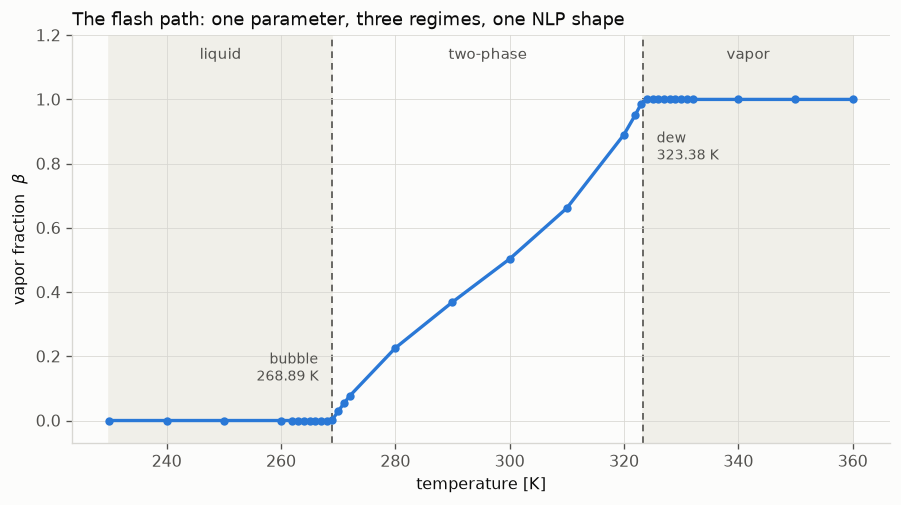

In [8]:
# --- shared chart style -------------------------------------------------
S1, S2 = "#2a78d6", "#eb6834"          # categorical slots 1 and 2
INK, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#d8d7d2", "#fcfcfb"
plt.rcParams.update({
    "figure.figsize": (7.6, 4.3), "figure.dpi": 120, "font.size": 9.5,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5, "axes.titlecolor": INK,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
    "figure.facecolor": SURF, "axes.facecolor": SURF, "lines.linewidth": 2.0,
})
import matplotlib.transforms as mtransforms

def regime_bands(ax, label=True):
    """Shade the single-phase regions; mark and name all three."""
    ax.axvspan(T_path.min(), T_bub, color="#f0efe9", zorder=0)
    ax.axvspan(T_dew, T_path.max(), color="#f0efe9", zorder=0)
    for t in (T_bub, T_dew):
        ax.axvline(t, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
    if label:
        tr = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        for xc, name in (((T_path.min() + T_bub) / 2, "liquid"),
                         ((T_bub + T_dew) / 2, "two-phase"),
                         ((T_dew + T_path.max()) / 2, "vapor")):
            ax.text(xc, 0.97, name, transform=tr, ha="center", va="top",
                    color=MUTED, fontsize=9)

fig, ax = plt.subplots()
ax.plot(T_path, beta_s, color=S1, marker="o", ms=4, zorder=3)
ax.set_ylim(-0.07, 1.20)
regime_bands(ax)
ax.annotate(f"bubble\n{T_bub:.2f} K", (T_bub, 0.0), textcoords="offset points",
            xytext=(-8, 24), ha="right", color=MUTED, fontsize=8.5)
ax.annotate(f"dew\n{T_dew:.2f} K", (T_dew, 1.0), textcoords="offset points",
            xytext=(8, -36), ha="left", color=MUTED, fontsize=8.5)
ax.set_xlabel("temperature [K]")
ax.set_ylabel(r"vapor fraction  $\beta$")
ax.set_title("The flash path: one parameter, three regimes, one NLP shape", loc="left")
fig.tight_layout()

$\beta$ is pinned at exactly 0 below the bubble point and exactly 1 above the dew
point -- not approximately. That is the complementarity doing its job: the bound is
active and carries a multiplier, rather than a Rachford--Rice root being clipped.

The more revealing plot is the pair of **stability slacks**. Each one is the $H$ side
of one complementarity pair, and each leaves zero exactly at its own switch point:

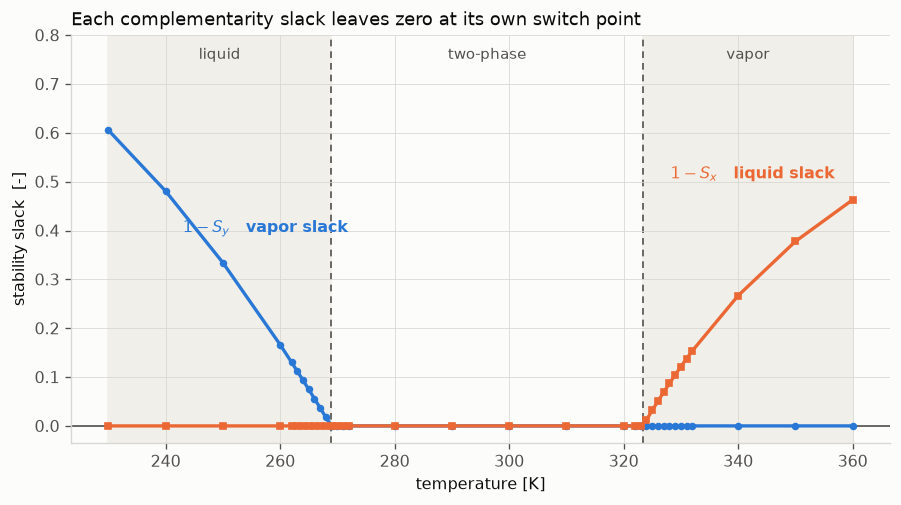

In [9]:
fig, ax = plt.subplots()
ax.plot(T_path, 1.0 - Sy_s, color=S1, marker="o", ms=3.5, zorder=3)
ax.plot(T_path, 1.0 - Sx_s, color=S2, marker="s", ms=3.5, zorder=3)
ax.axhline(0.0, color=MUTED, lw=1.0, zorder=2)
ax.set_ylim(-0.035, 0.80)
regime_bands(ax)
ax.annotate(r"$1-S_y$   vapor slack", (243.0, 0.395), color=S1,
            fontsize=9.5, fontweight="bold", ha="left")
ax.annotate(r"$1-S_x$   liquid slack", (357.0, 0.505), color=S2,
            fontsize=9.5, fontweight="bold", ha="right")
ax.set_xlabel("temperature [K]")
ax.set_ylabel("stability slack  [-]")
ax.set_title("Each complementarity slack leaves zero at its own switch point", loc="left")
fig.tight_layout()

Read it as the phase rule:

* **Below the bubble point** the vapour slack $1 - S_y$ is strictly positive: the
  liquid is stable against the incipient vapour, and $\beta = 0$ on the other side of
  pair V. The liquid slack is zero, because the liquid is a real phase.
* **Between the switches** *both* slacks are zero: both phases are real, both
  amounts are positive, and the isofugacity rows are the ordinary ones.
* **Above the dew point** the mirror image.
* **At each switch point** an amount and its own slack vanish together. Those are the
  two biactive points, and they are where the constraint qualifications fail hardest.

The same solve, plotted as composition against temperature, is the familiar $T$-$x$-$y$
diagram -- with a feature an ordinary flash routine does not produce. Outside the
two-phase lens the branches *continue*: they are the incipient phase the stability
test found, which the MPCC carries as real variables at every temperature.

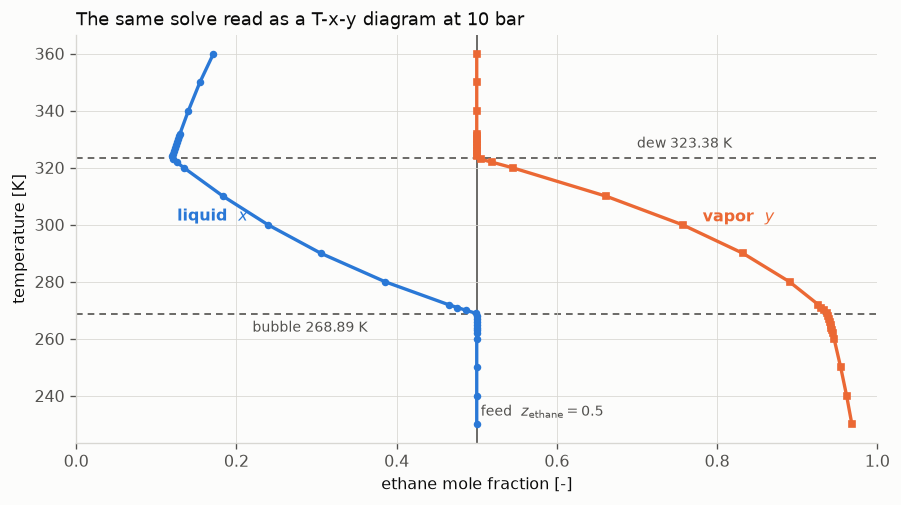

In [10]:
xl = np.array([s["x"][0] / s["x"].sum() for s in sol])
yv = np.array([s["y"][0] / s["y"].sum() for s in sol])
i300 = int(np.argmin(np.abs(T_path - 300.0)))

fig, ax = plt.subplots()
ax.plot(xl, T_path, color=S1, marker="o", ms=3.5, zorder=3)
ax.plot(yv, T_path, color=S2, marker="s", ms=3.5, zorder=3)
for t in (T_bub, T_dew):
    ax.axhline(t, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.axvline(0.5, color=MUTED, lw=1.0, zorder=1)
ax.text(0.505, T_path.min() + 3, r"feed  $z_{\rm ethane}=0.5$", color=MUTED, fontsize=8.5)
ax.text(0.22, T_bub - 2.5, f"bubble {T_bub:.2f} K", color=MUTED, fontsize=8.5,
        ha="left", va="top")
ax.text(0.70, T_dew + 2.5, f"dew {T_dew:.2f} K", color=MUTED, fontsize=8.5,
        ha="left", va="bottom")
ax.annotate("liquid  $x$", (xl[i300], T_path[i300]), textcoords="offset points",
            xytext=(-12, 2), ha="right", color=S1, fontsize=9.5, fontweight="bold")
ax.annotate("vapor  $y$", (yv[i300], T_path[i300]), textcoords="offset points",
            xytext=(12, 2), ha="left", color=S2, fontsize=9.5, fontweight="bold")
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("ethane mole fraction [-]")
ax.set_ylabel("temperature [K]")
ax.set_title("The same solve read as a T-x-y diagram at 10 bar", loc="left")
fig.tight_layout()

## 7. Verification, and the defect it caught

Agreement with the reference calculation, point by point. The dashed line is Gate 0's
complementarity accuracy floor $\sqrt{\mathrm{tol}} = 10^{-4}$ -- the resolution a
solve converged to `tol` is entitled to, because $G H$ is quadratically flat at the
corner. The answers sit eight orders below it.

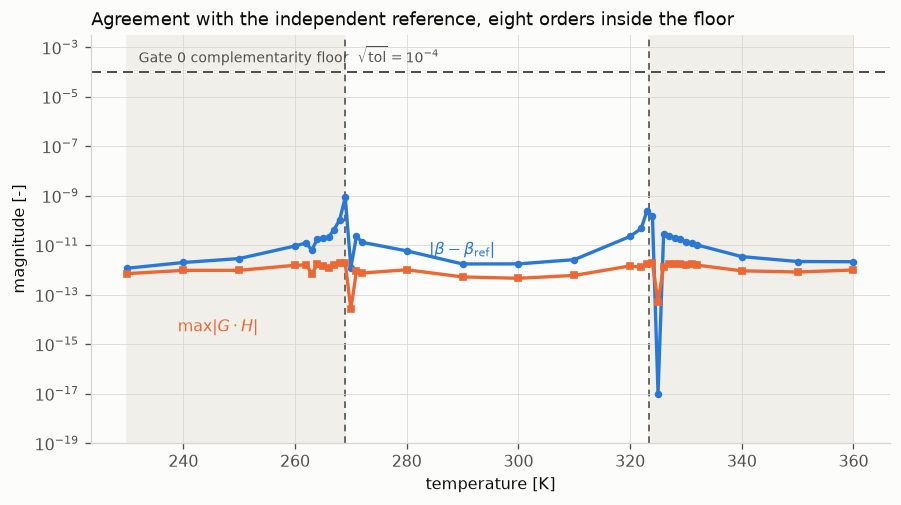

In [11]:
fig, ax = plt.subplots()
ax.semilogy(T_path, np.maximum(np.abs(beta_s - beta_r), 1e-17),
            color=S1, marker="o", ms=3.5, zorder=3)
ax.semilogy(T_path, np.maximum(compl, 1e-19), color=S2, marker="s", ms=3.5, zorder=3)
ax.axhline(CORNER_TOL, color=MUTED, lw=1.2, ls=(0, (5, 3)), zorder=2)
ax.set_ylim(1e-19, 3e-3)
regime_bands(ax, label=False)
ax.text(T_path.min() + 2, 1.6e-4,
        r"Gate 0 complementarity floor  $\sqrt{\mathrm{tol}}=10^{-4}$",
        color=MUTED, fontsize=8.5, va="bottom")
ax.annotate(r"$|\beta-\beta_{\rm ref}|$", (296, 4e-12), color=S1,
            fontsize=9.5, fontweight="bold", ha="right")
ax.annotate(r"$\max|G\cdot H|$", (239, 3e-15), color=S2, fontsize=9.5, fontweight="bold")
ax.set_xlabel("temperature [K]")
ax.set_ylabel("magnitude [-]")
ax.set_title("Agreement with the independent reference, eight orders inside the floor",
             loc="left")
fig.tight_layout()

The two peaks are at the switch points, which is where they belong: those are the
biactive points, and the accuracy the solver can deliver there is bounded by the
complementarity floor rather than by the solver's tolerance.

**Why this check is not ceremony.** The first implementation of this model normalised
inside the logarithm as well as inside $\varphi$ -- writing
$\ln(x_i/S_x) + \ln\varphi_i(x/S_x)$ where the tangent plane calls for
$\ln x_i + \ln\varphi_i(x/S_x)$. That adds $\ln(S_y/S_x)$ to every isofugacity row.
Here is what that term does along the path:

In [12]:
def defective_isofugacity(v, T):
    """The first implementation's row: normalised inside the log as well."""
    beta, x, y = case.unpack(v)
    sx, sy = x.sum(), y.sum()
    xn, yn = x / sx, y / sy
    lx = np.asarray(ln_phi(xn, T, case.pressure_pa, case.mixture, largest=False))
    ly = np.asarray(ln_phi(yn, T, case.pressure_pa, case.mixture, largest=True))
    return np.log(xn) + lx - np.log(yn) - ly

print(f"{'T [K]':>7} {'regime':>10} {'correct row':>13} {'defective row':>15} {'ln(Sy/Sx)':>12}")
for T in (240.0, 250.0, 268.0, 280.0, 300.0, 320.0, 330.0, 350.0):
    r = flash(T, case.pressure_pa, case.mixture)
    v = case.pack(r.beta, r.x, r.y)
    good = np.max(np.abs(case.isofugacity_residual(v, T)))
    bad = np.max(np.abs(defective_isofugacity(v, T)))
    print(f"{T:7.1f} {r.regime:>10} {good:13.2e} {bad:15.2e} "
          f"{np.log(r.sum_y / r.sum_x):12.3e}")

  T [K]     regime   correct row   defective row    ln(Sy/Sx)


  240.0     liquid      2.61e-14        6.55e-01   -6.555e-01


  250.0     liquid      1.02e-14        4.07e-01   -4.069e-01


  268.0     liquid      2.66e-14        1.75e-02   -1.749e-02


  280.0  two_phase      2.22e-16        2.22e-16   -1.110e-16


  300.0  two_phase      1.18e-15        1.18e-15    0.000e+00


  320.0  two_phase      1.05e-14        1.05e-14    0.000e+00


  330.0      vapor      3.92e-14        1.29e-01    1.293e-01


  350.0      vapor      5.22e-14        4.74e-01    4.743e-01


The defective row is **exactly zero in the two-phase region** -- where $S_x = S_y = 1$
and the spurious term vanishes identically -- and wrong by $\ln(S_y/S_x)$ everywhere
else. So the broken model solved, converged, and agreed with the reference at every
two-phase temperature. It was wrong only in the single-phase regimes: the ones this
fixture exists to reach.

A corpus that stopped at the two-phase region would have shipped it, and no NLP
residual would have complained. That is the argument for checking a physical model
against a second calculation rather than against its own convergence.

## 8. Two findings that only a phase-change model produces

### The supported route's second half does not apply to a square flash

Gate 0's `scholtes_then_ncp` finishes with one exact-product (`prod_eq`) solve seeded
from the continuation -- the half that turns a $\tau$-feasible answer into an
MPCC-feasible one. Try it here:

In [13]:
nlp_eq = lower(case, 300.0, "prod_eq")
prob = pounce.Problem(
    n=nlp_eq.n, m=nlp_eq.m, problem_obj=nlp_eq, lb=nlp_eq.lb, ub=nlp_eq.ub,
    cl=np.where(np.isfinite(nlp_eq.cl), nlp_eq.cl, -1e20),
    cu=np.where(np.isfinite(nlp_eq.cu), nlp_eq.cu, 1e20),
)
for k, val in OPTIONS.items():
    prob.add_option(k, val)
# Seeded from the continuation's own converged answer at 300 K -- the
# best possible start, so a failure here is structural rather than a
# question of initialization.
_, info_eq = prob.solve(x0=sol[i300]["v"])
print("finishing solve, seeded from the continuation:", info_eq["status_msg"])
print()
n_eq = int(np.sum(nlp_eq.cl == nlp_eq.cu))
print(f"variables            {nlp_eq.n}")
print(f"equality rows        {n_eq}   ({', '.join(np.array(nlp_eq.row_names)[nlp_eq.cl == nlp_eq.cu])})")
print(f"inequality rows      {nlp_eq.m - n_eq}")
print()
print("A square flash has no objective and no slack, so making both product rows")
print("equalities gives more equalities than variables. Gate 0's corpus had an")
print("objective and free variables and never met this; every equilibrium-stage")
print("model meets it by construction.")

finishing solve, seeded from the continuation: Not_Enough_Degrees_Of_Freedom

variables            5
equality rows        6   (balance_ethane, balance_n-butane, isofugacity_ethane, isofugacity_n-butane, prod_vapor, prod_liquid)
inequality rows      2

A square flash has no objective and no slack, so making both product rows
equalities gives more equalities than variables. Gate 0's corpus had an
objective and free variables and never met this; every equilibrium-stage
model meets it by construction.


Without a fallback that means the supported route runs its **continuation half only**,
at every one of the 34 temperatures. The answers above would still be right -- the
continuation reaches $\tau = 10^{-8}$ and the products land at $10^{-12}$ -- but the
half of the route that exists to *guarantee* MPCC-feasibility would never have run,
and a report saying "the supported route works on a phase-change model" would be
false in the way that matters.

The gate itself is not a defect. `application.rs` mirrors upstream Ipopt
(`IpOrigIpoptNLP.cpp:299`) deliberately, and an over-determined equality system
generically has no solution, so refusing it is the right default. The fix belongs in
the route: `Route.finish_fallback` substitutes the direct $G H \le 0$ lowering where
the equality form cannot run. The two have **identical feasible sets** -- with
$G, H \ge 0$ the inequality is active only at $G H = 0$ -- but an inequality does not
count against the gate. With that in place `scholtes_then_ncp` finishes here too, and
every record carries `finish_lowering` so the substitution is never invisible.

**It is a fallback and not a replacement, and that distinction is a measurement rather
than a caution.** Run unconditionally over *Gate 0's* corpus, the inequality finish
ties on cells solved (60) and on cells reaching the known optimum (57), and beats the
equality finish on complementarity by 27× -- and returns **three cells below the
MPCC's optimum where the equality finish returns none**. Identical feasible sets do
not imply identical converged points: an interior-point method reaches a different
point inside the same set depending on whether the constraint carries a free
multiplier or a sign-constrained one. Below-optimum is the one axis Gate 0 chose that
finish for, so the inequality form is used only where the equality form cannot run at
all.
### Reverse-mode autodiff loses the Hessian at the bubble point

The isofugacity rows carry a cubic root, and Cardano's trigonometric branch runs
`arccos` into its endpoint singularity where the cubic approaches a double root. Under
`jax.jit`, `jax.hessian` -- which is `jacfwd(jacrev(·))` -- loses the Lagrangian
Hessian entirely there. Forward-over-forward does not:

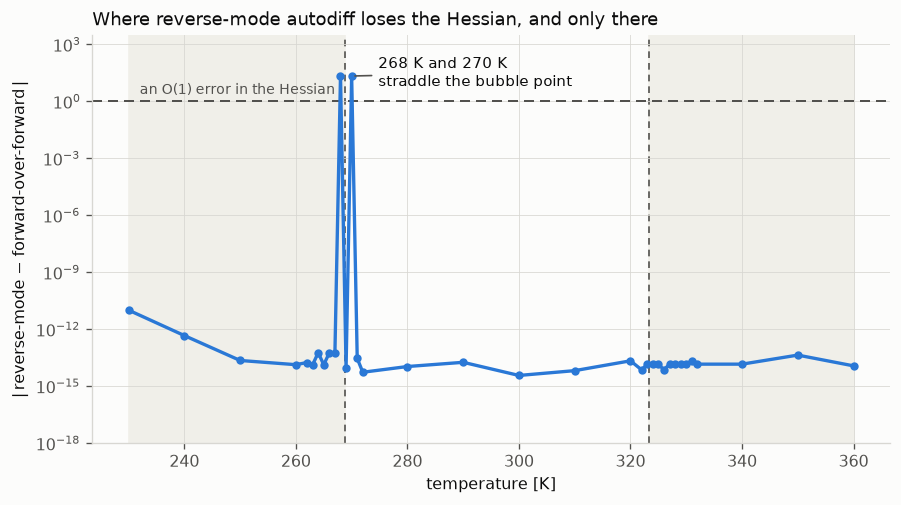

In [14]:
import jax.numpy as jnp
from pounce.examples.flash_mpcc import _residuals

lagrangian = lambda w, lam, T: jnp.dot(lam, _residuals(w, T, case))
H_reverse = jax.jit(jax.hessian(lagrangian, argnums=0))                        # jacfwd(jacrev)
H_forward = jax.jit(jax.jacfwd(jax.jacfwd(lagrangian, argnums=0), argnums=0))  # forward-over-forward

lam = jnp.asarray(np.random.default_rng(776).normal(size=8))
gap = []
for T in T_path:
    r = flash(float(T), case.pressure_pa, case.mixture)
    w = jnp.asarray(case.pack(r.beta, r.x, r.y))
    t = jnp.asarray(float(T))
    gap.append(float(np.max(np.abs(np.asarray(H_reverse(w, lam, t))
                                   - np.asarray(H_forward(w, lam, t))))))
gap = np.maximum(np.array(gap), 1e-18)

fig, ax = plt.subplots()
ax.semilogy(T_path, gap, color=S1, marker="o", ms=4, zorder=3)
ax.set_ylim(1e-18, 3e3)
regime_bands(ax, label=False)
ax.axhline(1.0, color=MUTED, lw=1.2, ls=(0, (5, 3)), zorder=2)
ax.text(T_path.min() + 2, 1.6, "an O(1) error in the Hessian",
        color=MUTED, fontsize=8.5, va="bottom")
ax.annotate("268 K and 270 K\nstraddle the bubble point",
            (270.0, gap[int(np.argmin(np.abs(T_path - 270.0)))]),
            textcoords="offset points", xytext=(16, -6), ha="left", color=INK,
            fontsize=9, arrowprops=dict(arrowstyle="-", color=MUTED, lw=1.0))
ax.set_xlabel("temperature [K]")
ax.set_ylabel(r"$|\,$reverse-mode $-$ forward-over-forward$\,|$")
ax.set_title("Where reverse-mode autodiff loses the Hessian, and only there", loc="left")
fig.tight_layout()

Fourteen orders of magnitude, at two path points, and machine precision everywhere
else. The Jacobian is unaffected in every mode -- which is why this is dangerous
rather than merely wrong: gradients, KKT residuals and *converged answers* were all
correct. The traversal above agreed with the reference to $10^{-11}$ at all 34
temperatures while the Hessian was wrong. It cost iterations and robustness at exactly
the point the fixture exists to test, and nothing reported it.

`pounce.examples.flash_mpcc` therefore builds its Hessian with
`jacfwd(jacfwd(·))`, which is exact here and costs the same.

## 9. What this notebook is not evidence about

* **More than one flash.** Two components, five variables, one equilibrium stage, one
  operating parameter. Nothing here bounds a tray, a column, or a dynamic
  transcription -- gh#776 gates those on this result, and this result does not reach
  them.
* **Competitiveness.** Section 2 measured the honest comparison and the complementarity
  form loses it. The case for the formulation is composability into a larger
  simultaneous problem, and this notebook does not demonstrate that larger problem.
* **The DiscOpt half of Gate 1.** The reduced GDP/SOS1 regime cross-validation is
  blocked on the two live DiscOpt slices —
  [#1147](https://github.com/jkitchin/discopt/issues/1147) then
  [#1148](https://github.com/jkitchin/discopt/issues/1148) — and was not run.
  [#1123](https://github.com/jkitchin/discopt/issues/1123) is closed and is the
  design record, not the blocker.
* **Supercritical mixture states.** The path stays far from the mixture critical
  point. Ethane is above its own $T_c$ over the top third of it, which is ordinary and
  is not the same thing.
* **Global optimality.** POUNCE is a local solver. The reference calculation's
  stability test is a multistart, which is a stronger claim than the MPCC's single
  stationary point -- that asymmetry is deliberate, and it is why agreement is
  evidence and disagreement would be a finding about the MPCC.
* **Nonlinear complementarity functions.** The pairs here are affine in the variables;
  the nonlinearity is in the ordinary rows.

The full route matrix, the four-leg hysteresis check, and the machine-readable result
contract live in [`benchmarks/flash/`](https://github.com/jkitchin/pounce/tree/main/benchmarks/flash);
`python/tests/test_flash_mpcc.py` is the fast regression.